# <span style="color:darkblue"> Lecture 10b - Word Clouds </span>

<font size = "5">

In  this lecture we will work with text data

- Basic summary and data manipulation
- Generate word clouds!

# <span style="color:darkblue"> I. Import Libraries and Data </span>

<font size = "5">

Start by installing "wordcloud" using <br>
conda install in your terminal

<font size = "5">

Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud, STOPWORDS

<font size = "5">

Import Data

- Congressional bills in the United States

In [3]:
bills_actions = pd.read_csv("data_raw/bills_actions.csv")
bills_actions.dtypes

Congress        int64
bill_number     int64
bill_type      object
action         object
main_action    object
category       object
member_id       int64
dtype: object

# <span style="color:darkblue"> II. Word Clouds from Single Strings  </span>

<font size = "5">

Word Cloud from sentence

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

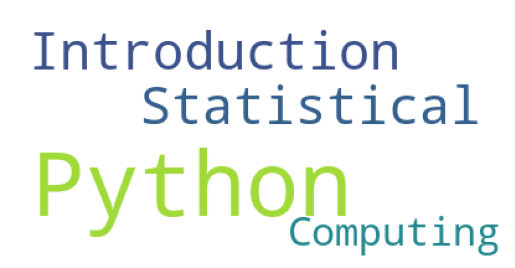

In [5]:
# We start by generating a string with text
# The WordCloud() command generates and object. To display it use "plt.imgshow()"
# Words with higher frequency will tend to appear larger (see advanced options)
# at the end for how to adjust the relative scaling

text = "Introduction to Statistical Computing Python Python Python Python Python"
word_cloud = WordCloud(background_color = "white").generate(text)
plt.imshow(word_cloud)
plt.axis("off")

<font size = "5">

Get word frequencies

In [6]:
word_frequencies = WordCloud().process_text(text)
word_frequencies

{'Introduction': 1, 'Statistical': 1, 'Computing': 1, 'Python': 5}

<font size = "5">

Adding stop words

- WordCloud drops common words like "to, from, the, a, ..."
- They're stored in STOPWORDS. We can add more!

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

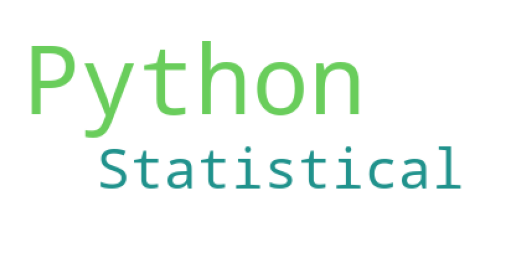

In [7]:
# Create adjusted list of stop words

stop_words = list(STOPWORDS) + ["Introduction","Computing"]
text = "Introduction to Statistical Computing Python Python Python Python Python"

# Plot results
# If you don't wan't any stopwords, use "stopwords = []" instead
word_cloud = WordCloud(background_color = "white",
                       stopwords = stop_words).generate(text)
plt.imshow(word_cloud)
plt.axis("off")

<font size = "5">

Try it yourself!

- Search in Wikipedia for an article.
- Copy a paragraph into Python and store it as <br>
a string variable called "text".
- Display a word cloud!

(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

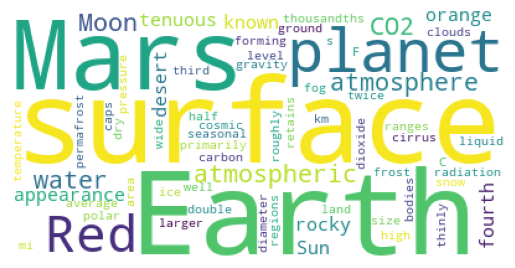

In [8]:
# Write your own code


text = """Mars is the fourth planet from the Sun. 
It is also known as the "Red Planet", because of its orange-red appearance.[22][23]
Mars is a desert-like rocky planet with a tenuous atmosphere that is primarily carbon dioxide (CO2). 
At the average surface level the atmospheric pressure is a few thousandths of Earth’s, 
atmospheric temperature ranges from −153 to 20 °C (−243 to 68 °F)[24] and cosmic radiation is high.
Mars retains some water, in the ground as well as thinly in the atmosphere, forming cirrus clouds, fog, frost, larger polar regions of permafrost and ice caps (with seasonal CO2 snow), but no bodies of liquid surface water.
Its surface gravity is roughly a third of Earth's or double that of the Moon. 
It is about half as wide as Earth or twice the Moon, with a diameter of 6,779 km (4,212 mi), and has a surface area the size of all the dry land of Earth."""

word_cloud = WordCloud(background_color = "white",
                       stopwords = stop_words).generate(text)
plt.imshow(word_cloud)
plt.axis("off")

In [9]:
word_frequencies = WordCloud().process_text(text)
word_frequencies

{'Mars': 3,
 'fourth': 1,
 'planet': 3,
 'Sun': 1,
 'known': 1,
 'Red': 2,
 'orange': 1,
 'appearance': 1,
 'desert': 1,
 'rocky': 1,
 'tenuous': 1,
 'atmosphere': 2,
 'primarily': 1,
 'carbon': 1,
 'dioxide': 1,
 'CO2': 2,
 'average': 1,
 'surface': 4,
 'level': 1,
 'atmospheric': 2,
 'pressure': 1,
 'thousandths': 1,
 'Earth': 4,
 's': 1,
 'temperature': 1,
 'ranges': 1,
 'C': 1,
 'F': 1,
 'cosmic': 1,
 'radiation': 1,
 'high': 1,
 'retains': 1,
 'water': 2,
 'ground': 1,
 'well': 1,
 'thinly': 1,
 'forming': 1,
 'cirrus': 1,
 'clouds': 1,
 'fog': 1,
 'frost': 1,
 'larger': 1,
 'polar': 1,
 'regions': 1,
 'permafrost': 1,
 'ice': 1,
 'caps': 1,
 'seasonal': 1,
 'snow': 1,
 'bodies': 1,
 'liquid': 1,
 'gravity': 1,
 'roughly': 1,
 'third': 1,
 'double': 1,
 'Moon': 2,
 'half': 1,
 'wide': 1,
 'twice': 1,
 'diameter': 1,
 'km': 1,
 'mi': 1,
 'area': 1,
 'size': 1,
 'dry': 1,
 'land': 1}

# <span style="color:darkblue"> III. Word Clouds + Pandas </span>

<font size = "5">

Concatanate column into single long sentence

In [8]:
# We start of with an empty string and sequentiall
# concatenate all the elements of bills["main_action"] together

list_categories = ["house bill","senate bill"]
bills = bills_actions.query('category in @list_categories')

text_bills = "".join(bills["action"])

<font size = "5">

Create WordCloud

(-0.5, 399.5, 199.5, -0.5)

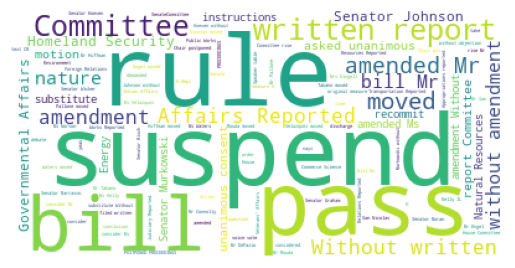

In [9]:
#stopwords = list(STOPWORDS) + ["Introduction","Computing"]
#text = "Introduction to Statistical Computing Python Python Python Python Python"

word_cloud = WordCloud(background_color = "white").generate(text_bills)
                       
plt.imshow(word_cloud)
plt.axis("off")

<font size = "5">

Text by subgroup

In [10]:
# Create sets of words by category
subset_bills_house  = bills_actions.query('category == "house bill"')
subset_bills_senate = bills_actions.query('category == "senate bill"')

# Create strings with all the words mentioned for those observations
text_house  = "".join(subset_bills_house["action"])
text_senate = "".join(subset_bills_senate["action"])

<font size = "5" >
Plotting multiple wordclouds

Text(0.5, 1.0, 'Senate')

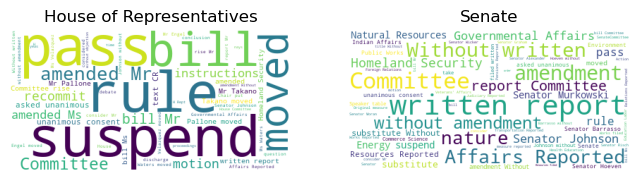

In [11]:
# Use subplots to create figures with multiple plots
fig, list_subfig = plt.subplots(1,2,figsize = [8,3])

word_cloud_house = WordCloud(background_color = "white").generate(text_house)                       
list_subfig[0].imshow(word_cloud_house)
list_subfig[0].axis("off")
list_subfig[0].set_title("House of Representatives")

word_cloud_senate = WordCloud(background_color = "white").generate(text_senate)                       
list_subfig[1].imshow(word_cloud_senate)
list_subfig[1].axis("off")
list_subfig[1].set_title("Senate")

<font size = "5">

**Note:** In general, many possibilities for splitting by subgroups! <br>
Years, geography, type of speaker, type of document, etc.

<font size = "5">
Try it yourself!

- Obtain the text for the categories "house resolution" <br>
and "senate resolution" (separately)
- Plot word clouds for the column "action" for each of the <br>
two categories using ``` plt.subplots()``` and the code <br>
shown above


In [11]:
# Write your own code





# <span style="color:darkblue"> V. (Optional) Advanced Settings </span>

(-0.5, 399.5, 199.5, -0.5)

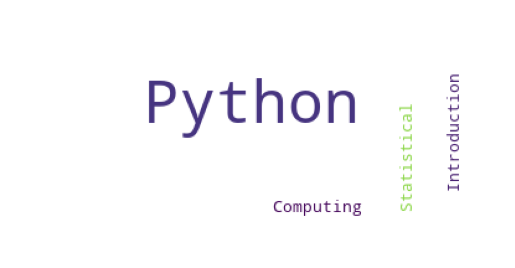

In [15]:
# Relative scaling of high-frequency words

text = "Introduction to Statistical Computing Python Python Python Python Python"
word_cloud = WordCloud(width = 400,
                       height = 200,
                       relative_scaling = 0.9, # or "auto"
                       background_color = "white").generate(text)
plt.imshow(word_cloud)
plt.axis("off")